In [63]:
from google.colab import drive

In [64]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [66]:
df=pd.read_csv("/content/drive/MyDrive/ML_projects/Hierarchial_clustering/Country-data.csv")

In [67]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [68]:
df.shape

(167, 10)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [70]:
df[['income', 'gdpp']] = df[['income', 'gdpp']].astype(float)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    float64
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    float64
dtypes: float64(9), object(1)
memory usage: 13.2+ KB


### Univariate Analysis of Numerical Features

Let's visualize the distribution of each numerical feature using histograms and boxplots. Histograms show the frequency distribution, while boxplots can help identify outliers and the spread of the data. We will also calculate the skewness for each feature to understand the asymmetry of its distribution.

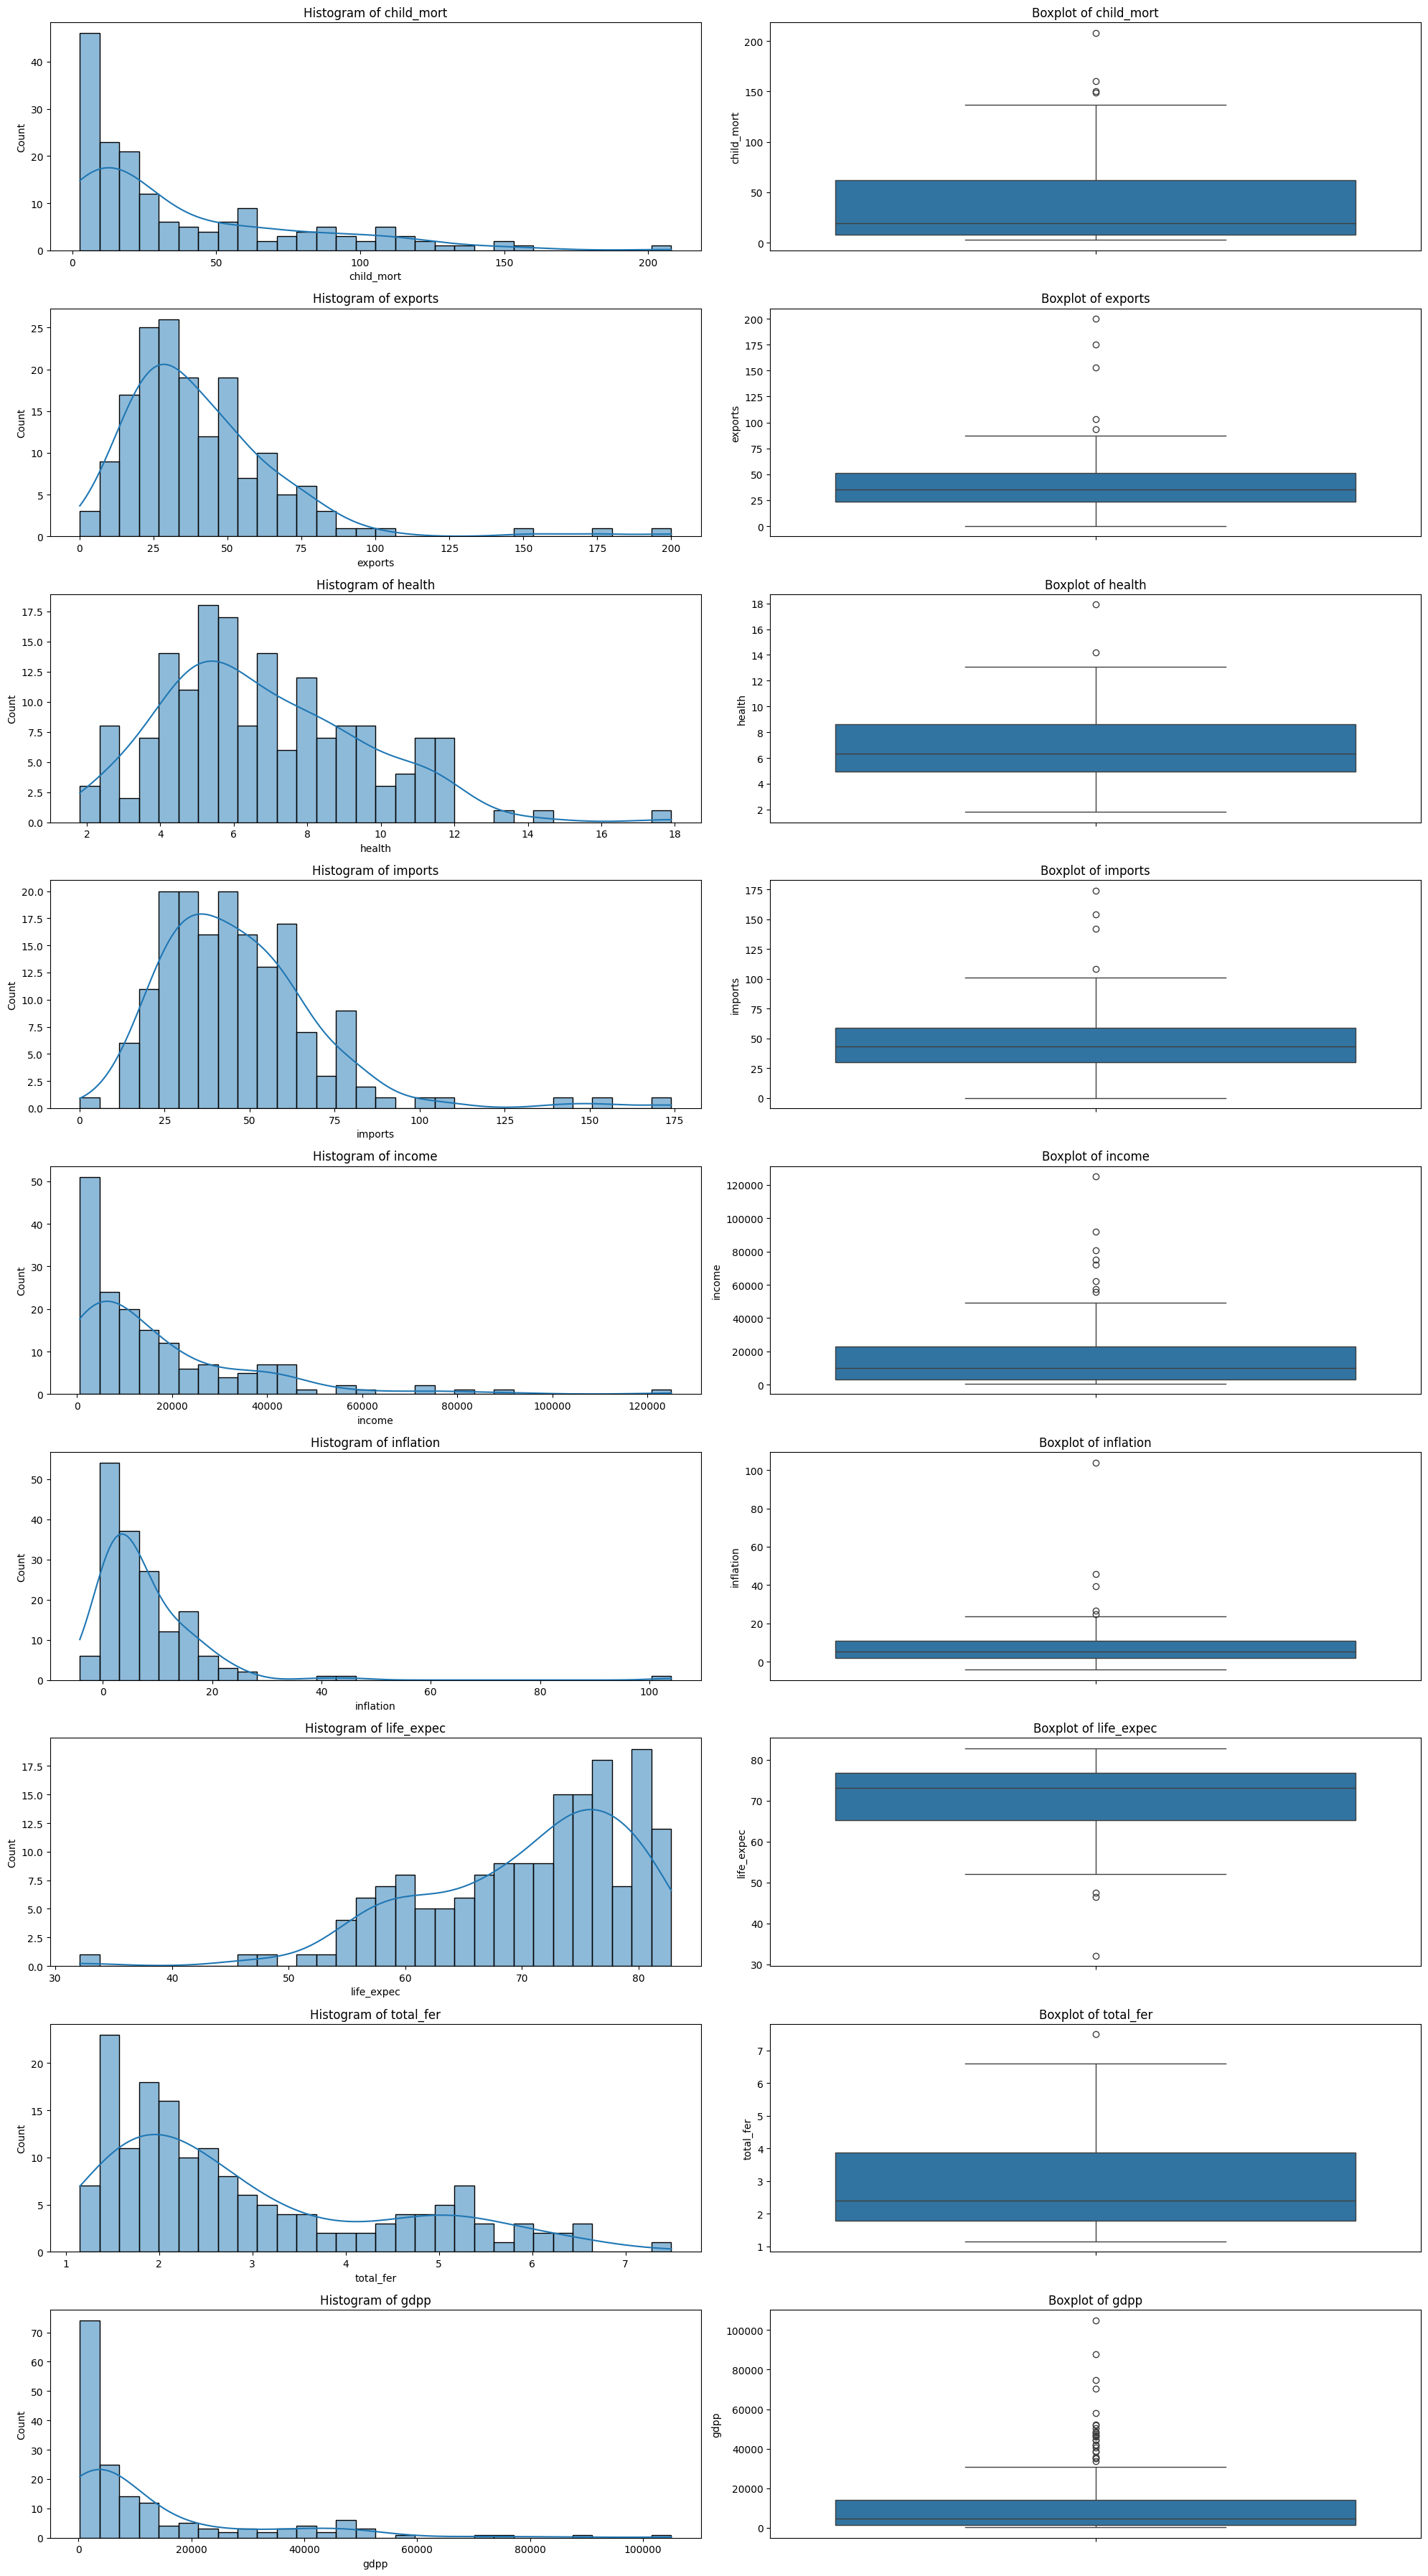


Skewness of each numerical feature:
child_mort    1.450774
exports       2.445824
health        0.705746
imports       1.905276
income        2.231480
inflation     5.154049
life_expec   -0.970996
total_fer     0.967092
gdpp          2.218051
dtype: float64


In [72]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 2, 2 * i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')

    plt.subplot(len(numerical_cols), 2, 2 * i + 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

print("\nSkewness of each numerical feature:")
print(df[numerical_cols].skew())

Now that you have the histograms, boxplots, and skewness values, how would you interpret these results?

*   **Histograms:** What do the shapes of the histograms tell you about the distribution of each feature (e.g., symmetric, left-skewed, right-skewed)?
*   **Boxplots:** Do you notice any outliers in the boxplots? How do these plots confirm or contradict what you see in the histograms?
*   **Skewness values:** Generally, a skewness value between -0.5 and 0.5 is considered approximately symmetric. Values outside this range indicate significant skewness. Which features appear to be highly skewed based on these numbers?

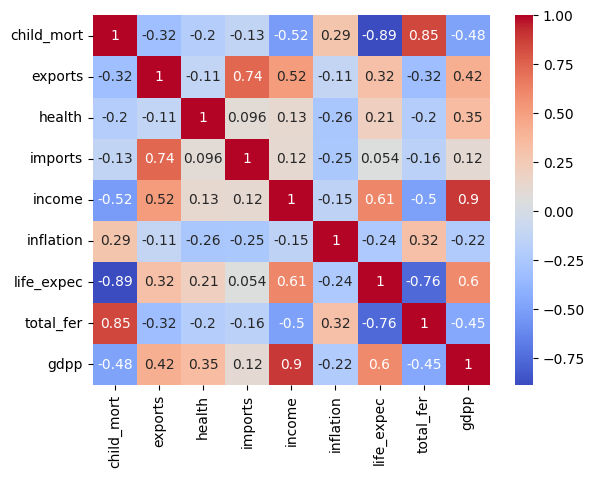

In [73]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

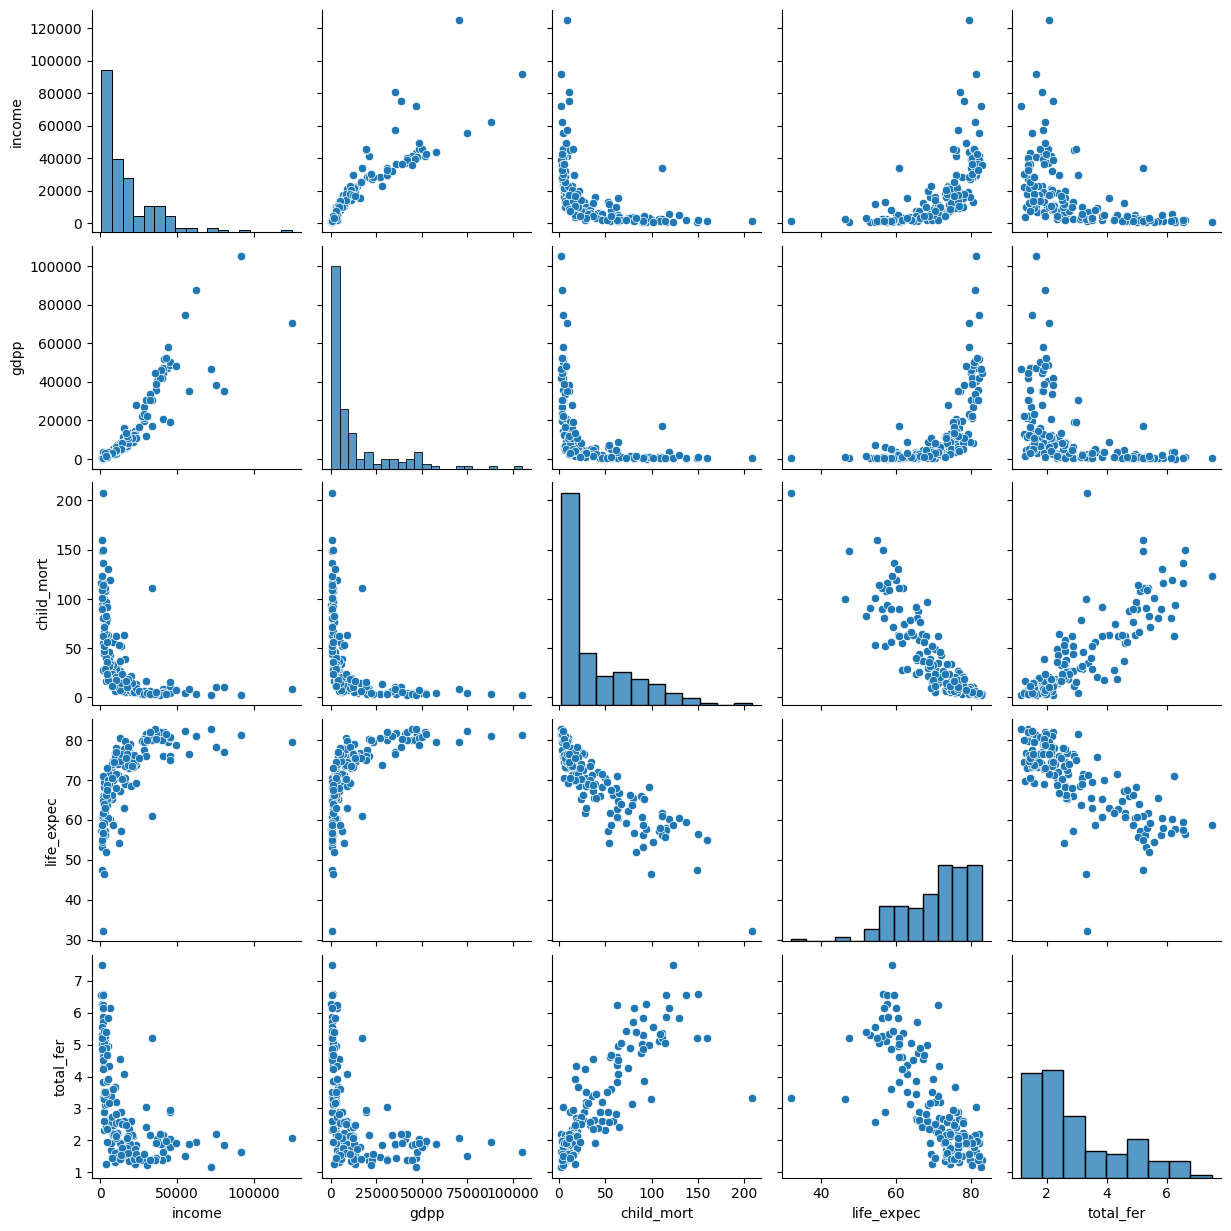

In [74]:
features = ['income', 'gdpp', 'child_mort', 'life_expec', 'total_fer']


sns.pairplot(df[features])
plt.show()

In [75]:
df.drop(['income','life_expec'],axis=1,inplace=True)

In [76]:
df

,country,child_mort,exports,health,imports,inflation,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,9.44,5.82,553.0
1,Albania,16.6,28.0,6.55,48.6,4.49,1.65,4090.0
2,Algeria,27.3,38.4,4.17,31.4,16.10,2.89,4460.0
3,Angola,119.0,62.3,2.85,42.9,22.40,6.16,3530.0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,1.44,2.13,12200.0
...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2.62,3.50,2970.0
163,Venezuela,17.1,28.5,4.91,17.6,45.90,2.47,13500.0
164,Vietnam,23.3,72.0,6.84,80.2,12.10,1.95,1310.0
165,Yemen,56.3,30.0,5.18,34.4,23.60,4.67,1310.0


In [77]:
skewed_feature=['child_mort','exports','health','imports','inflation','total_fer','gdpp']

df[skewed_feature]=np.log(df[skewed_feature])

In [78]:
df.dropna(inplace=True)

In [79]:
df

,country,child_mort,exports,health,imports,inflation,total_fer,gdpp
0,Afghanistan,4.502029,2.302585,2.025513,3.804438,2.244956,1.761300,6.315358
1,Albania,2.809403,3.332205,1.879465,3.883624,1.501853,0.500775,8.316300
2,Algeria,3.306887,3.648057,1.427916,3.446808,2.778819,1.061257,8.402904
3,Angola,4.779123,4.131961,1.047319,3.758872,3.109061,1.818077,8.169053
4,Antigua and Barbuda,2.332144,3.817712,1.796747,4.075841,0.364643,0.756122,9.409191
...,...,...,...,...,...,...,...,...
162,Vanuatu,3.374169,3.841601,1.658228,3.964615,0.963174,1.252763,7.996317
163,Venezuela,2.839078,3.349904,1.591274,2.867899,3.826465,0.904218,9.510445
164,Vietnam,3.148453,4.276666,1.922788,4.384524,2.493205,0.667829,7.177782
165,Yemen,4.030695,3.401197,1.644805,3.538057,3.161247,1.541159,7.177782


In [80]:
from sklearn.preprocessing import RobustScaler
features=['child_mort','exports','health','imports','inflation','total_fer','gdpp']
scaler = RobustScaler()
X=scaler.fit_transform(df[features])

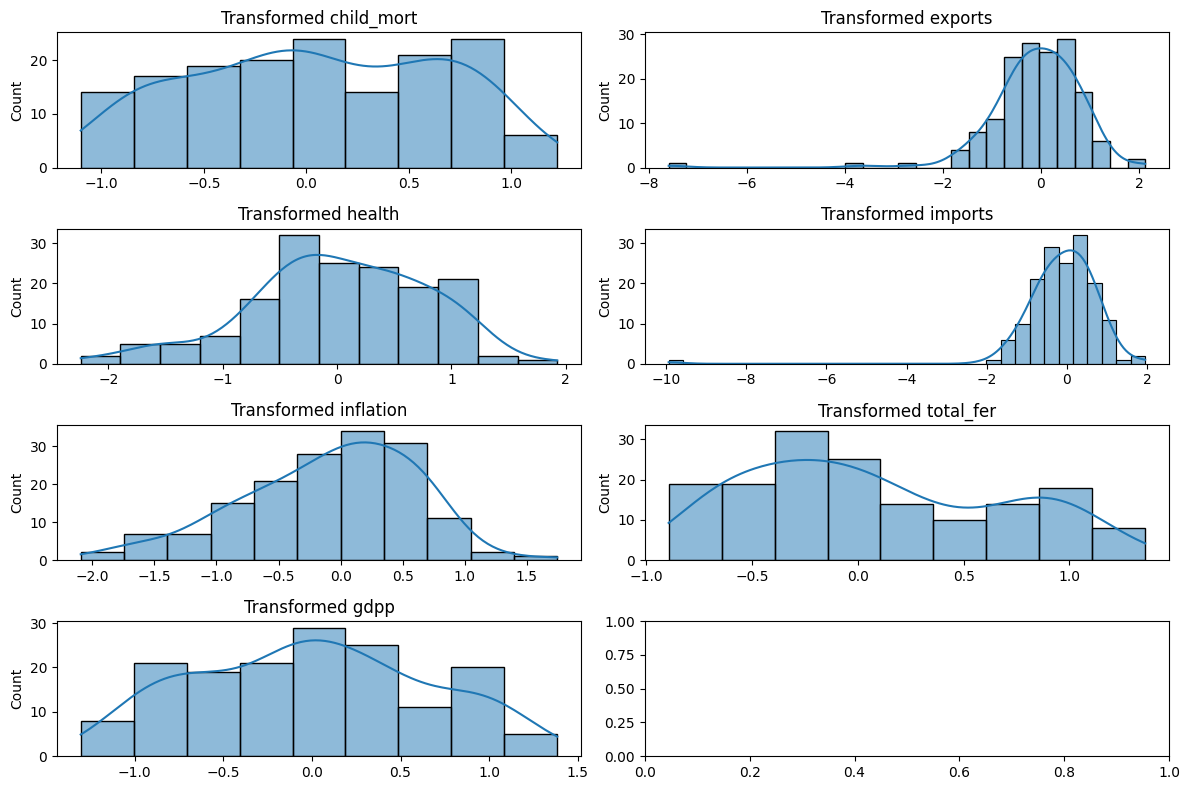

In [81]:
fig, axes = plt.subplots(
    nrows=(len(features) + 1) // 2,
    ncols=2,
    figsize=(12, 8)
)

axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(X[:, i], kde=True, ax=axes[i])
    axes[i].set_title(f'Transformed {col}')

plt.tight_layout()
plt.show()

In [82]:
print("\nSkewness of each numerical feature:")
print(df[features].skew())


Skewness of each numerical feature:
child_mort   -0.061686
exports      -2.984905
health       -0.387206
imports      -5.325114
inflation    -0.473661
total_fer     0.340771
gdpp          0.082501
dtype: float64


In [83]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
X=pt.fit_transform(df[features])

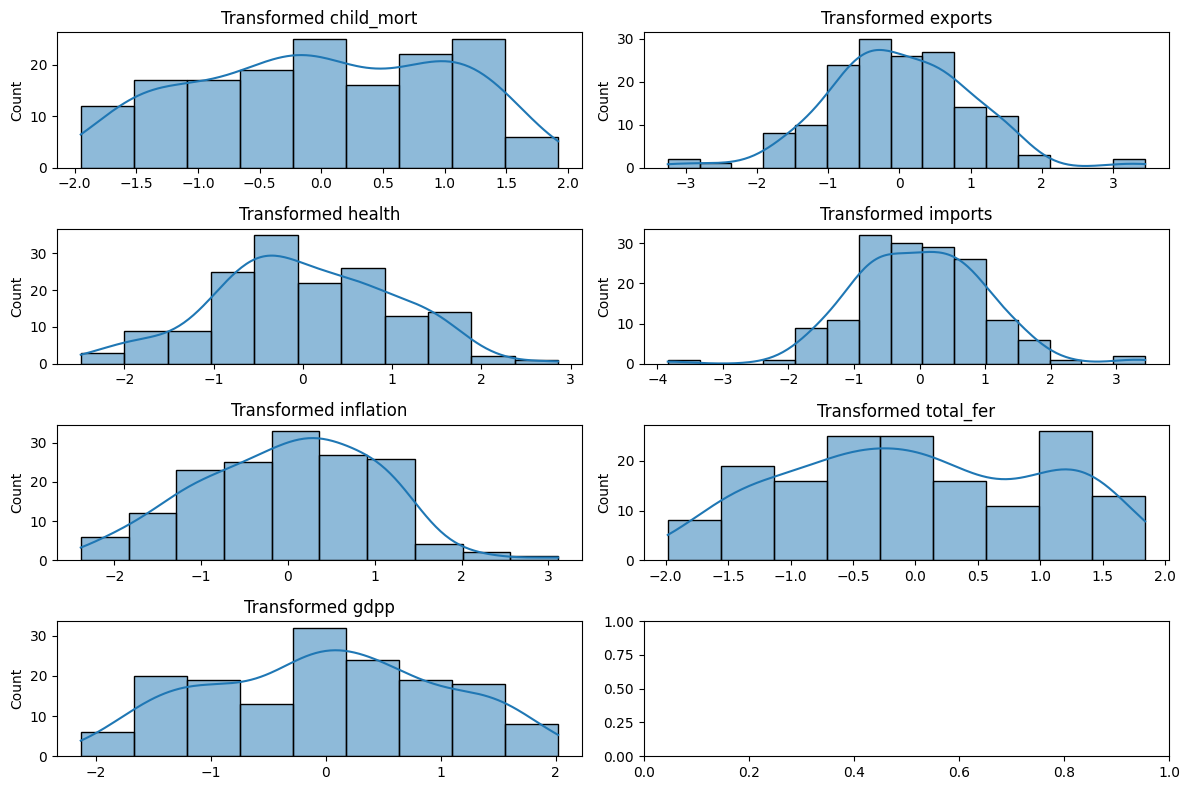

In [84]:
fig, axes = plt.subplots(
    nrows=(len(features) + 1) // 2,
    ncols=2,
    figsize=(12, 8)
)

axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(X[:, i], kde=True, ax=axes[i])
    axes[i].set_title(f'Transformed {col}')

plt.tight_layout()
plt.show()

In [85]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,15):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

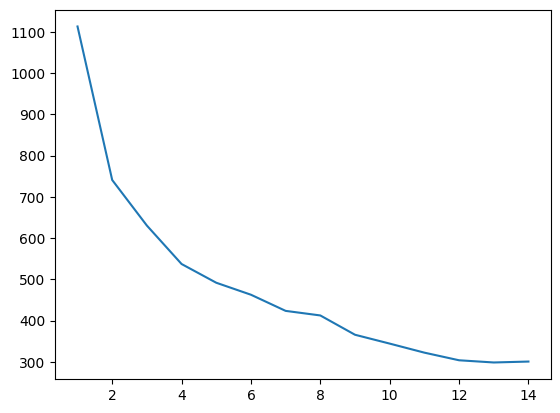

In [86]:
plt.plot(range(1,15),wcss)

In [87]:
from sklearn.metrics import silhouette_score
silhouette_scores = []


for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

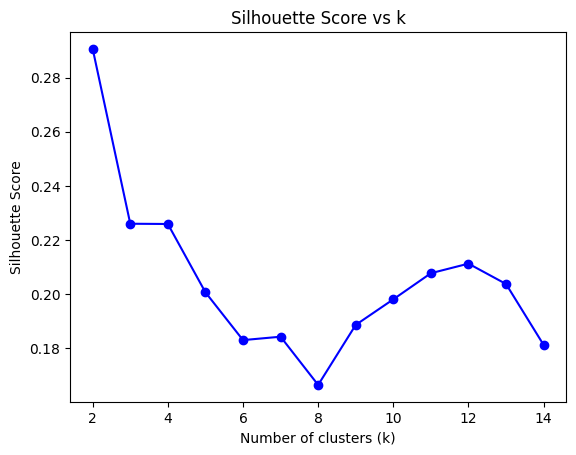

In [88]:
# Plot silhouette score vs k
plt.plot(range(2,15), silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.show()

# The k with the highest silhouette score is optimal
optimal_k = range(2,15)[np.argmax(silhouette_scores)]

In [89]:
# Print WCSS values
print("WCSS values:")
for k, w in enumerate(wcss, 1):
    print(f"  k={k}: {w:.2f}")

# Print Silhouette scores
print("\nSilhouette scores:")
for k, s in zip(range(2, 15), silhouette_scores):
    print(f"  k={k}: {s:.4f}")

WCSS values:
  k=1: 1113.00
  k=2: 740.84
  k=3: 630.39
  k=4: 537.25
  k=5: 491.82
  k=6: 462.76
  k=7: 423.62
  k=8: 412.54
  k=9: 365.76
  k=10: 344.30
  k=11: 322.38
  k=12: 303.89
  k=13: 298.55
  k=14: 300.78

Silhouette scores:
  k=2: 0.2906
  k=3: 0.2260
  k=4: 0.2259
  k=5: 0.2007
  k=6: 0.1831
  k=7: 0.1843
  k=8: 0.1665
  k=9: 0.1887
  k=10: 0.1981
  k=11: 0.2078
  k=12: 0.2113
  k=13: 0.2038
  k=14: 0.1813


In [90]:
# Phase 2.1 - Fit KMeans with optimal k=3
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X)
# Phase 2.3 - Cluster Interpretation (original scale)
# Use the original df before log-transform to interpret clusters meaningfully
# We need to reload original data and merge cluster labels
df_original = pd.read_csv("/content/drive/MyDrive/ML_projects/Hierarchial_clustering/Country-data.csv")
df_original.drop(['income', 'life_expec'], axis=1, inplace=True)
df_original = df_original.iloc[df.index]  # align with rows after dropna
df_original['cluster'] = df['cluster'].values

# Mean feature values per cluster (original scale)
cluster_profiles = df_original.groupby('cluster')[['child_mort', 'exports', 'health', 'imports', 'inflation', 'total_fer', 'gdpp']].mean()
cluster_profiles
# Number of countries per cluster
df_original['cluster'].value_counts().sort_index()

,count
cluster,
0,31
1,38
2,26
3,35
4,29


In [91]:
cluster_profiles = (
    df_original
    .groupby('cluster')[[
        'child_mort', 'exports', 'health',
        'imports', 'inflation', 'total_fer', 'gdpp'
    ]]
    .mean()
    .round(2)
)

cluster_profiles

,child_mort,exports,health,imports,inflation,total_fer,gdpp
cluster,,,,,,,
0,6.07,36.00,9.88,38.61,2.15,1.78,32742.90
1,37.20,47.38,5.53,53.98,9.10,3.15,4746.47
2,9.27,69.39,6.32,65.45,5.46,1.72,21510.38
3,96.42,23.11,7.13,45.49,8.20,5.17,881.09
4,38.65,24.32,5.16,23.51,16.24,2.71,5048.62


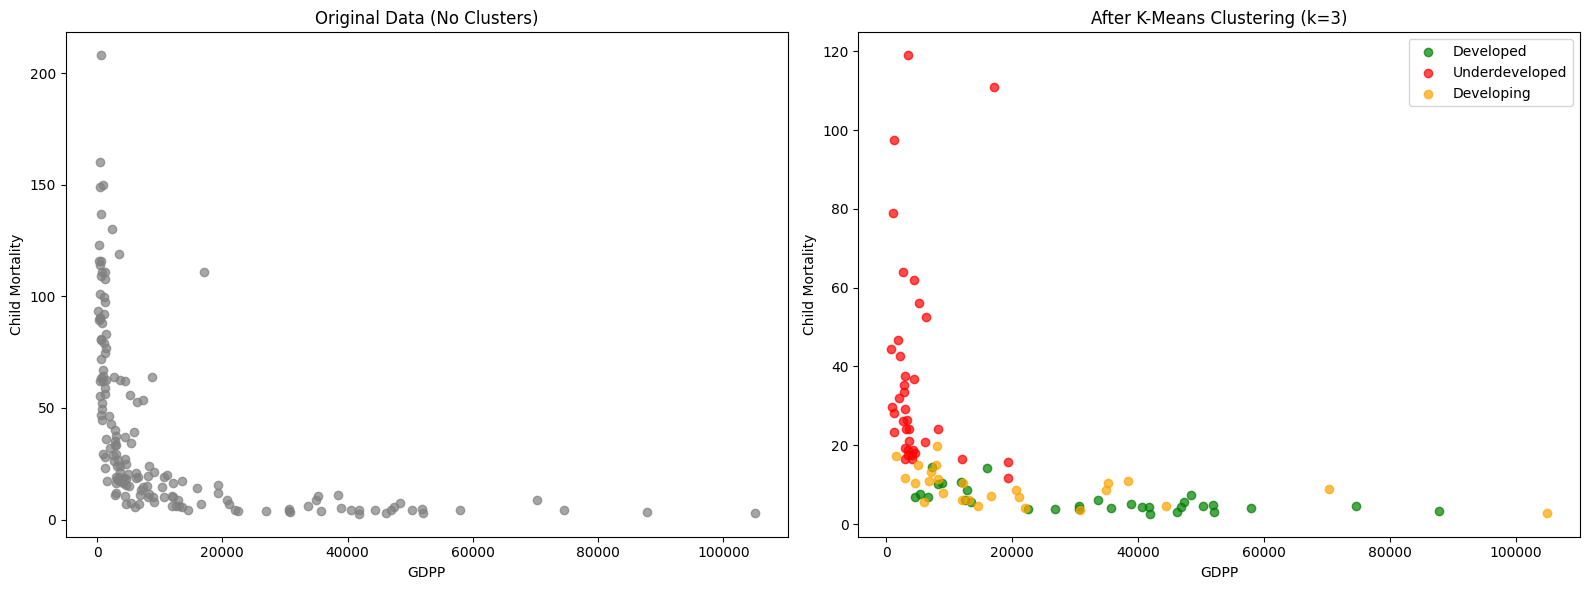

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_original['gdpp'], df_original['child_mort'], c='gray', alpha=0.7)
axes[0].set_title('Original Data (No Clusters)')
axes[0].set_xlabel('GDPP')
axes[0].set_ylabel('Child Mortality')

axes[1].scatter(df_original[df_original['cluster'] == 0]['gdpp'], df_original[df_original['cluster'] == 0]['child_mort'],
                c='green', label='Developed', alpha=0.7)
axes[1].scatter(df_original[df_original['cluster'] == 1]['gdpp'], df_original[df_original['cluster'] == 1]['child_mort'],
                c='red', label='Underdeveloped', alpha=0.7)
axes[1].scatter(df_original[df_original['cluster'] == 2]['gdpp'], df_original[df_original['cluster'] == 2]['child_mort'],
                c='orange', label='Developing', alpha=0.7)
axes[1].set_title('After K-Means Clustering (k=3)')
axes[1].set_xlabel('GDPP')
axes[1].set_ylabel('Child Mortality')
axes[1].legend()

plt.tight_layout()
plt.show()

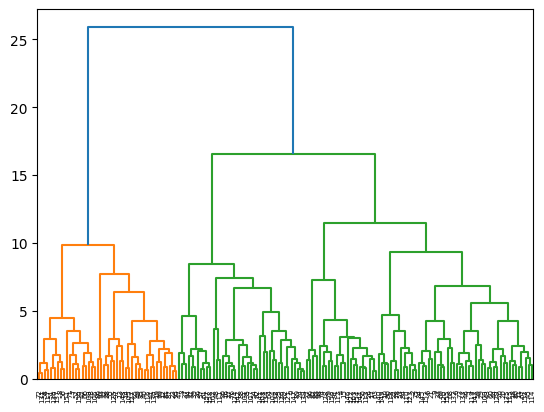

In [109]:
import scipy.cluster.hierarchy as sch
dend=sch.dendrogram(sch.linkage(X,method='ward'))

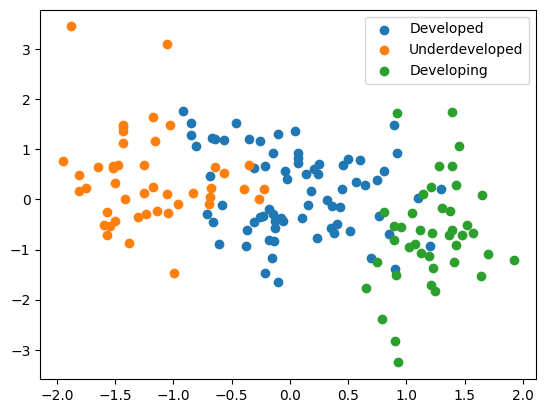

In [115]:
from sklearn.cluster import AgglomerativeClustering
cluster=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
labels=cluster.fit_predict(X)
plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='Developed')
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='Underdeveloped')
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='Developing')

plt.legend()
plt.show()